In [3]:
!pip install -q langchain-mistralai langgraph python-dotenv

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI

In [5]:
from google.colab import userdata
import os
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')

In [6]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [7]:
# DELIBERATELY hardcoded -- see MISTRAL_MODEL_LIMITS.md: mistral-small-latest
# has zero request allowance on many accounts (hard 429).
subgraph_llm = ChatMistralAI(model="ministral-8b-latest")

In [15]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Urdu.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [16]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [17]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [18]:
parent_llm = ChatMistralAI(model="ministral-8b-latest")

In [19]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [20]:
def translate_answer(state: ParentState):
    # call the subgraph
    # THE KEY IDEA: subgraph.invoke(...) is called just like any other
    # function -- a fully compiled graph is itself invokable, exactly the
    # same way a node function is. The PARENT graph doesn't know or care
    # that "translate" internally runs a whole separate graph; from the
    # parent's perspective, this node just returns a dict, like any other.
    #
    # NOTE the state SHAPE MISMATCH being bridged manually here: the parent's
    # ParentState has 'answer_eng', but the subgraph's SubState expects
    # 'input_text'. This function explicitly maps one to the other on the
    # way in, and maps SubState's 'translated_text' back to ParentState's
    # 'answer_hin' on the way out. Subgraphs do NOT automatically share field
    # names with the parent -- you translate between the two state shapes
    # yourself, as this function does.
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [21]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

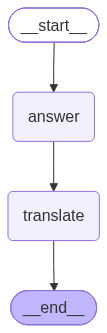

In [22]:
graph = parent_builder.compile()

graph

In [23]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (or **quantum mechanics**) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically **atoms and subatomic particles** (like electrons, photons, and quarks). Unlike classical physics (which describes everyday objects like balls, cars, and planets), quantum physics reveals that at these tiny scales, nature behaves in strange, counterintuitive ways governed by **probability, waves, and discrete units of energy**.\n\n---\n\n### **Key Principles of Quantum Physics**\n1. **Wave-Particle Duality**\n   - Particles (e.g., electrons) can behave as both **particles** (localized objects) and **waves** (spread out in space).\n   - Example: Light acts as a wave (interference patterns) but also as particles (photons) in the photoelectric effect.\n\n2. **Quantization**\n   - Energy is not continuous but comes in **discrete packets** called **quanta** (e.g., photons carry energy i